In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 500)

In [4]:
df_raw = pd.read_csv("../data/raw/ChestX-ray14/Data_Entry_2017.csv")

In [5]:
df_raw.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [6]:
df_raw.info

<bound method DataFrame.info of              Image Index          Finding Labels  Follow-up #  Patient ID  \
0       00000001_000.png            Cardiomegaly            0           1   
1       00000001_001.png  Cardiomegaly|Emphysema            1           1   
2       00000001_002.png   Cardiomegaly|Effusion            2           1   
3       00000002_000.png              No Finding            0           2   
4       00000003_000.png                  Hernia            0           3   
...                  ...                     ...          ...         ...   
112115  00030801_001.png          Mass|Pneumonia            1       30801   
112116  00030802_000.png              No Finding            0       30802   
112117  00030803_000.png              No Finding            0       30803   
112118  00030804_000.png              No Finding            0       30804   
112119  00030805_000.png              No Finding            0       30805   

        Patient Age Patient Gender View Pos

In [7]:
df_raw.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,0.0
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649,NaN
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174,NaN
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,NaN
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000,NaN
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000,NaN
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,NaN
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800,NaN


In [9]:
df_raw["Finding Labels"].value_counts(dropna=False).head(10)

Finding Labels
No Finding                  60361
Infiltration                 9547
Atelectasis                  4215
Effusion                     3955
Nodule                       2705
Pneumothorax                 2194
Mass                         2139
Effusion|Infiltration        1603
Atelectasis|Infiltration     1350
Consolidation                1310
Name: count, dtype: int64

In [13]:
view_counts = df_raw["Finding Labels"].value_counts()
print(view_counts[:5])

Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64


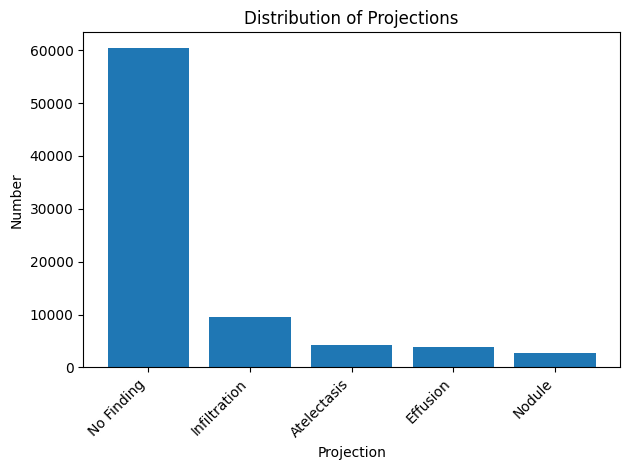

In [14]:
plt.figure()
view_counts = df_raw["Finding Labels"].value_counts()
plt.bar(view_counts[:5].index, view_counts[:5].values)
plt.title("Distribution of Projections")
plt.xlabel("Projection")
plt.ylabel("Number")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
label_sex_crosstab = (df_raw.explode("Finding Labels").pivot_table(index="Finding Labels", columns="Patient Gender", 
                                   aggfunc="size", fill_value=0).sort_values(by=["F", "M"], ascending=False))
label_sex_crosstab[:5]

Patient Gender,F,M
Finding Labels,,
No Finding,26439,33922
Infiltration,4164,5383
Effusion,1797,2158
Atelectasis,1612,2603
Pneumothorax,1193,1001


<Figure size 640x480 with 0 Axes>

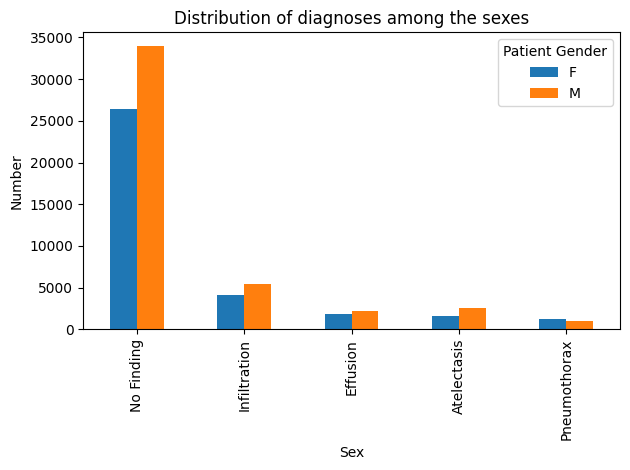

In [20]:
plt.figure()

label_sex_crosstab[:5].plot(kind="bar")
plt.title("Distribution of diagnoses among the sexes")
plt.xlabel("Sex")
plt.ylabel("Number")
plt.tight_layout()
plt.show()